**Analysis of Evaluation Dataset Paragraph Sizes for Chunking**

In [ ]:
import tiktoken
import numpy as np
import matplotlib.pyplot as plt
from config import DATASET_DIR
from utils import save_fig
from dataset_preprocessing.preprocess import parse_paper, Paper, MIN_PARAGRAPH_SIZE

enc = tiktoken.get_encoding("cl100k_base")

def plot_sizes(chunk_sizes: list[int], title: str, save: bool, annotation: str = None) -> None:
    median = np.median(chunk_sizes)

    plt.plot(chunk_sizes)
    plt.title(label=title, loc='center')
    plt.axhline(y=median, color='red', linestyle='--', label=f'Median: {median:.1f}')
    plt.legend()
    plt.ylabel("# Tokens")
    if annotation:
        plt.figtext(0.5, -0.02, "Note: " + annotation, ha="center", fontsize=9, color="gray")
    if save:
        save_fig(title)

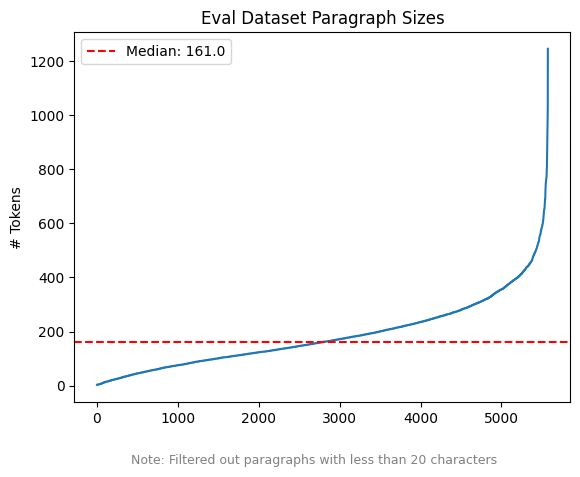

In [ ]:
DIR = DATASET_DIR / "papers"

def count_section_sizes(sec) -> list[int]:
    sizes = []
    for c in sec.children:
        if isinstance(c, str):
            sizes.append(len(enc.encode(c)))
        else:
            sizes.extend(count_section_sizes(c))
    return sizes

count_no_xml = 0
chunk_sizes: list[int] = []
for paper_dir in DIR.iterdir():
    xml_path = next(paper_dir.glob("*.xml"), None)
    if xml_path is None:
        count_no_xml += 1
        continue
    
    paper: Paper = parse_paper(xml_path)
    chunk_sizes.append(len(enc.encode(paper.abstract)))

    for sec in paper.sections:
        chunk_sizes.extend(count_section_sizes(sec))
    
chunk_sizes.sort()

plot_sizes(chunk_sizes,
                 title="Eval Dataset Paragraph Sizes",
                 save=True,
                 annotation=f"Filtered out paragraphs with less than {MIN_PARAGRAPH_SIZE} characters (likely noise)")